# Land-Use Fraction

Create a CMIP7 monthly land-use fraction file (`fracLut_tpt-u-hxy-u`) using time-point, land-use, latitude, and longitude coordinates.

In [1]:
from pathlib import Path
import json
import shutil

import cmor
from IPython.display import display
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import xarray as xr

TABLES_DIR = "../cmip7-cmor-tables/tables"
CV_PATH = "../cmip7-cmor-tables/tables-cvs/cmor-cvs.json"
DATA_PATH = Path("data") / "fracLut_Emon_GFDL-ESM4_land-noLu_r1i1p1f1_gr1_200702-200711.nc"
if not Path(TABLES_DIR).exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")
if not Path(CV_PATH).exists():
    raise FileNotFoundError(f"CMIP7 CV file not found: {CV_PATH}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Source data file not found: {DATA_PATH}")

print(f"Using CMIP7 tables from {TABLES_DIR}")


Using CMIP7 tables from ../cmip7-cmor-tables/tables


In [2]:
with xr.open_dataset(DATA_PATH, decode_times=False) as opened:
    source = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(source)


<xarray.Dataset> Size: 8MB
Dimensions:    (time: 10, landuse: 4, lat: 180, lon: 288, bnds: 2)
Coordinates:
  * time       (time) float64 80B 1.122e+05 1.122e+05 ... 1.124e+05 1.125e+05
  * landuse    (landuse) int32 16B 0 1 2 3
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * bnds       (bnds) float64 16B 1.0 2.0
Data variables:
    fracLut    (time, landuse, lat, lon) float32 8MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    lat_bnds   (lat, bnds) float64 3kB -90.0 -89.0 -89.0 ... 89.0 89.0 90.0
    lon_bnds   (lon, bnds) float64 5kB 0.0 1.25 1.25 2.5 ... 358.8 358.8 360.0
    time_bnds  (time, bnds) float64 160B 1.122e+05 1.122e+05 ... 1.125e+05
Attributes:
    external_variables:    areacella
    history:               File was processed by fremetar (GFDL analog of CMO...
    table_id:              Emon
    activity_id:           LUMIP
    branch_method:         no parent
    branch_time_in_child:  0.0
    comment:               <null ref>
    contact:               gfdl.climate.model.info@noaa.gov
    Conventions:           CF-1.7 CMIP-6.0 UGRID-1.0
    creation_date:         2019-08-25T02:53:14Z
    data_specs_version:    01.00.27
    experiment:            historical land-only with no land-use change
    experiment_id:         land-noLu
    forcing_index:         1
    frequency:             mon
    further_info_url:      https://furtherinfo.es-doc.org/CMIP6.NOAA-GFDL.GFD...
    grid:                  land data regridded from Cubed-sphere (c96) to 180...
    grid_label:            gr1
    initialization_index:  1
    institution:           National Oceanic and Atmospheric Administration, G...
    institution_id:        NOAA-GFDL
    license:               CMIP6 model data produced by NOAA-GFDL is licensed...
    mip_era:               CMIP6
    nominal_resolution:    100 km
    parent_activity_id:    no parent
    parent_experiment_id:  no parent
    parent_mip_era:        no parent
    parent_source_id:      no parent
    parent_time_units:     no parent
    parent_variant_label:  no parent
    physics_index:         1
    product:               model-output
    realization_index:     1
    realm:                 land
    source:                GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-sphere...
    source_id:             GFDL-ESM4
    source_type:           LAND BGC
    sub_experiment:        none
    sub_experiment_id:     none
    title:                 NOAA GFDL GFDL-ESM4 model output prepared for CMIP...
    tracking_id:           hdl:21.14100/3325dad3-4bc4-454e-8ab0-53c12ba60e51
    variable_id:           fracLut
    variant_info:          N/A
    references:            see further_info_url attribute
    variant_label:         r1i1p1f1

In [3]:
run_dir = Path("output") / "06_land_use_fraction"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_PATH,
    "activity_id": "CMIP",
    "calendar": source["time"].attrs.get("calendar", "standard"),
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "nominal_resolution": "100 km",
    "outpath": str(output_dir),
    "physics_index": "p1",
    "realization_index": "r9",
    "region": "glb",
    "source_id": "DUMMY-MODEL",
}
input_json = run_dir / "input.json"
input_json.write_text(json.dumps(DATASET_INFO, indent=2, sort_keys=True))

time = source["time"].values.astype("f8")
time_units = source["time"].attrs["units"]
lat = source["lat"].values.astype("f8")
lat_bnds = source["lat_bnds"].values.astype("f8")
lon = source["lon"].values.astype("f8")
lon_bnds = source["lon_bnds"].values.astype("f8")
landuse = [
    "primary_and_secondary_land",
    "pastures",
    "crops",
    "urban",
]

missing_value = np.float32(1.0e20)
frac_lut_source = source["fracLut"].values.astype("f4")
frac_lut = np.where(np.isfinite(frac_lut_source), frac_lut_source, missing_value).astype("f4")

print(frac_lut.shape)


(10, 4, 180, 288)


In [4]:
cmor.setup(
    inpath=TABLES_DIR,
    netcdf_file_action=cmor.CMOR_REPLACE,
    logfile=str(run_dir / "cmor.log"),
)
cmor.dataset_json(str(input_json))
cmor.load_table("CMIP7_land.json")

time_id = cmor.axis("time1", coord_vals=time, units=time_units)
landuse_id = cmor.axis("landuse", coord_vals=landuse, units="1")
lat_id = cmor.axis("latitude", coord_vals=lat, cell_bounds=lat_bnds, units="degrees_north")
lon_id = cmor.axis("longitude", coord_vals=lon, cell_bounds=lon_bnds, units="degrees_east")

variable_name = "fracLut_tpt-u-hxy-u"
frac_lut_id = cmor.variable(variable_name, "%", [time_id, landuse_id, lat_id, lon_id], missing_value=missing_value)
compound_name = ".".join(["land"] + variable_name.split("_") + ["mon", "glb"])

with open(Path(TABLES_DIR) / "CMIP7_cell_measures.json") as handle:
    cell_measure = json.load(handle)["cell_measures"].get(compound_name)
if cell_measure:
    cmor.set_variable_attribute(frac_lut_id, "cell_measures", "c", cell_measure)

with open(Path(TABLES_DIR) / "CMIP7_long_name_overrides.json") as handle:
    long_name = json.load(handle)["long_name_overrides"].get(compound_name)
if long_name:
    cmor.set_variable_attribute(frac_lut_id, "long_name", "c", long_name)

cmor.write(frac_lut_id, frac_lut)
netcdf_path = Path(cmor.close(frac_lut_id, file_name=True))
cmor.close()

print(netcdf_path.resolve().relative_to(Path.cwd().resolve()))


output/06_land_use_fraction/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/glb/mon/fracLut/tpt-u-hxy-u/g999/v20260531/fracLut_tpt-u-hxy-u_mon_glb_g999_DUMMY-MODEL_amip_r9i1p1f3_200702-200711.nc


In [5]:
with xr.open_dataset(netcdf_path, decode_times=False) as opened:
    ds = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(ds)


<xarray.Dataset> Size: 8MB
Dimensions:   (lat: 180, bnds: 2, lon: 288, time: 10, landuse: 4)
Coordinates:
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * time      (time) float64 80B 1.122e+05 1.122e+05 ... 1.124e+05 1.125e+05
    sector    (landuse) |S26 104B b'primary_and_secondary_land' ... b'urban'
Dimensions without coordinates: bnds, landuse
Data variables:
    lat_bnds  (lat, bnds) float64 3kB -90.0 -89.0 -89.0 -88.0 ... 89.0 89.0 90.0
    lon_bnds  (lon, bnds) float64 5kB 0.0 1.25 1.25 2.5 ... 358.8 358.8 360.0
    fracLut   (time, landuse, lat, lon) float32 8MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            u
    branded_variable:      fracLut_tpt-u-hxy-u
    branding_suffix:       tpt-u-hxy-u
    creation_date:         2026-05-31T18:49:31Z
    data_specs_version:    MIP-DS7.1.0.0
    description:           Simulation of the climate of the recent past with ...
    drs_specs:             MIP-DRS7
    experiment:            Simulation of the climate of the recent past with ...
    experiment_id:         amip
    external_variables:    areacella
    forcing_index:         f3
    frequency:             mon
    grid_label:            g999
    history:               2026-05-31T18:49:31Z ; CMOR rewrote data to be con...
    horizontal_label:      hxy
    host_collection:       CMIP7
    initialization_index:  i1
    institution:           Environment and Climate Change Canada
    institution_id:        CCCma
    license_id:            CC-BY-4.0
    mip_era:               CMIP7
    nominal_resolution:    100 km
    physics_index:         p1
    product:               model-output
    realization_index:     r9
    realm:                 land
    region:                glb
    source:                DUMMY-MODEL: aerosol: Dummy Aerosol; atmosphere: D...
    source_id:             DUMMY-MODEL
    table_info:            Name: CMIP7_land.json; Creation Date:(2026-04-21 1...
    temporal_label:        tpt
    title:                 DUMMY-MODEL output prepared for CMIP7
    tracking_id:           hdl:21.14107/0d2144de-0837-47c3-b1ad-763c1f94c0f9
    variable_id:           fracLut
    variant_label:         r9i1p1f3
    vertical_label:        u
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1

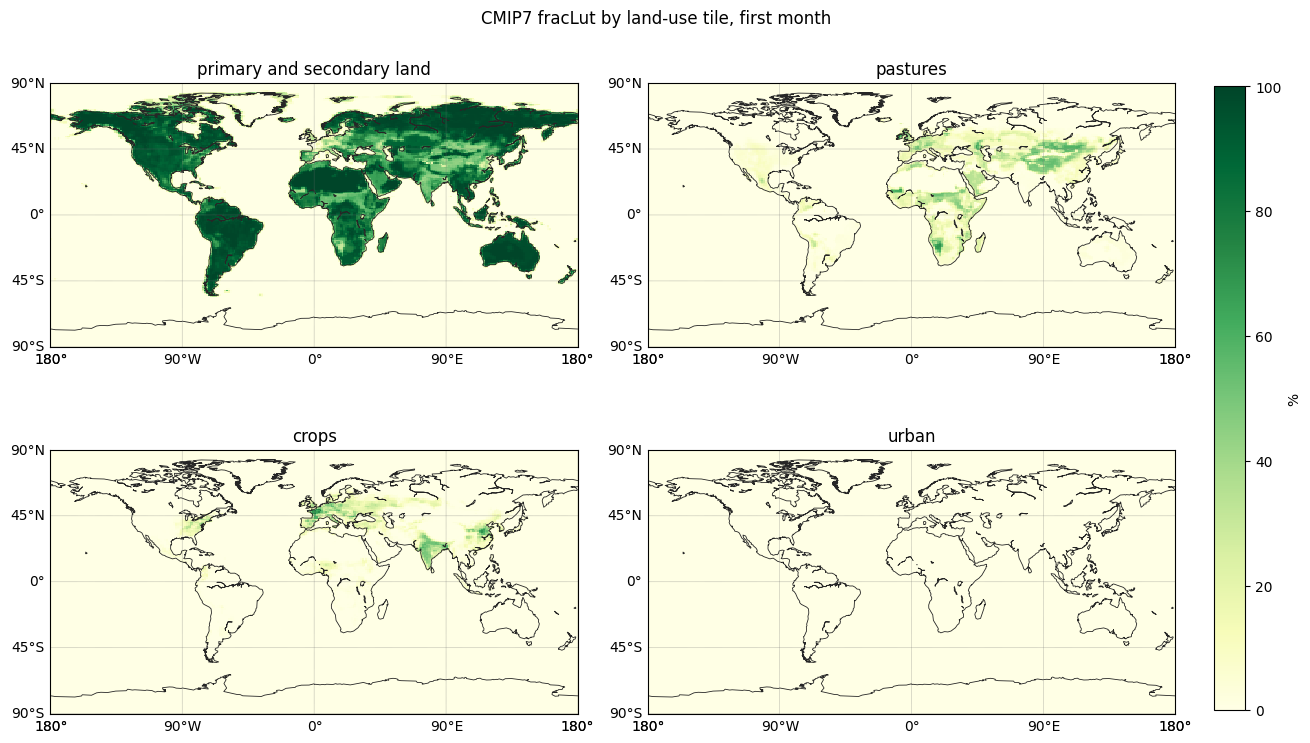

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.6), constrained_layout=True)
lon_wrapped = ((ds["lon"].values + 180.0) % 360.0) - 180.0
lon_order = np.argsort(lon_wrapped)
lon_grid, lat_grid = np.meshgrid(lon_wrapped[lon_order], ds["lat"].values)

for axis, landuse_index, landuse_name in zip(axes.ravel(), range(len(landuse)), landuse):
    map_plot = Basemap(
        projection="cyl",
        llcrnrlon=-180,
        urcrnrlon=180,
        llcrnrlat=-90,
        urcrnrlat=90,
        resolution="c",
        ax=axis,
    )
    map_plot.drawmapboundary(fill_color="#f7fbff", linewidth=0.8)
    x, y = map_plot(lon_grid, lat_grid)
    field = ds["fracLut"].isel(time=0, landuse=landuse_index).values[:, lon_order]
    mesh = map_plot.pcolormesh(x, y, field, shading="auto", cmap="YlGn", vmin=0, vmax=100)
    map_plot.drawcoastlines(linewidth=0.6, color="0.15")
    map_plot.drawparallels(np.arange(-90, 91, 45), labels=[1, 0, 0, 0], linewidth=0.35, color="0.45", dashes=[1, 1])
    map_plot.drawmeridians(np.arange(-180, 181, 90), labels=[0, 0, 0, 1], linewidth=0.35, color="0.45", dashes=[1, 1])
    axis.set_title(landuse_name.replace("_", " "))

colorbar = fig.colorbar(mesh, ax=axes, location="right", shrink=0.86, pad=0.02)
colorbar.set_label("%")
fig.suptitle("CMIP7 fracLut by land-use tile, first month")
plt.show()
